# Проверка гипотезы: сравнение групп (наблюдательные данные)
## Online Retail II (UCI)

Транзакционные данные британского онлайн-ритейлера (2009-2011). Считаем ключевые метрики, строим когортную матрицу Retention и проводим **наблюдательное сравнение групп** по стране.

> **Важно.** Это НЕ A/B-тест. Группы (UK / Германия) не формировались случайным сплитом. Различия могут объясняться конфаундерами (ассортимент, доля оптовиков, логистика), а не страной как таковой. Настоящие рандомизированные A/B-тесты — в Project_3.

### 1. Импорт библиотек, загрузка и проверка данных

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('../data/online_retail_II.csv')
print(df.shape)

(1067371, 8)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [3]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


### 2. Очистка данных

В сырых данных есть строки, которые искажают метрики выручки:
- отрицательные/нулевые `Quantity` и `Price` — это возвраты и служебные записи;
- пустой `Customer ID` — транзакции без привязки к покупателю.

Убираем их и вводим корректную выручку строки: **`revenue = Quantity * Price`**.

In [4]:
before = df.shape[0]
clean = df.dropna(subset=['Customer ID']).copy()
clean = clean[(clean['Quantity'] > 0) & (clean['Price'] > 0)].copy()
clean['revenue'] = clean['Quantity'] * clean['Price']
clean['InvoiceDate'] = pd.to_datetime(clean['InvoiceDate'])
print(f'Было строк:   {before:,}')
print(f'Стало строк:  {clean.shape[0]:,}')
print(f'Удалено:      {before - clean.shape[0]:,}')

Было строк:   1,067,371
Стало строк:  805,549
Удалено:      261,822


### 3. ARPPU на очищенных данных

ARPPU = суммарная выручка (`Quantity * Price`) / число уникальных покупателей.

> В исходной версии ARPPU считался как `Price.sum() / nunique` — это сумма цен за единицу товара без учёта количества, что некорректно.

In [5]:
arppu = clean['revenue'].sum() / clean['Customer ID'].nunique()
print(f"Суммарная выручка:      {clean['revenue'].sum():,.0f} GBP")
print(f"Уникальных покупателей: {clean['Customer ID'].nunique():,}")
print(f"ARPPU: {arppu:,.2f} GBP")

Суммарная выручка:      17,743,429 GBP
Уникальных покупателей: 5,878
ARPPU: 3,018.62 GBP


### 4. Помесячная выручка

In [6]:
clean['purchase_month'] = clean['InvoiceDate'].dt.to_period('M')
grouped_df = clean.groupby('purchase_month').agg(
    revenue_agg=('revenue', 'sum'),
    customer_id_agg=('Customer ID', 'nunique')).reset_index()
grouped_df.tail(15)

,purchase_month,revenue_agg,customer_id_agg
10,2010-10,1036680.000,1497
11,2010-11,1172336.042,1607
12,2010-12,884591.890,885
13,2011-01,569445.040,741
14,2011-02,447137.350,758
15,2011-03,595500.760,974
16,2011-04,469200.361,856
17,2011-05,678594.560,1056
18,2011-06,661213.690,991
19,2011-07,600091.011,949


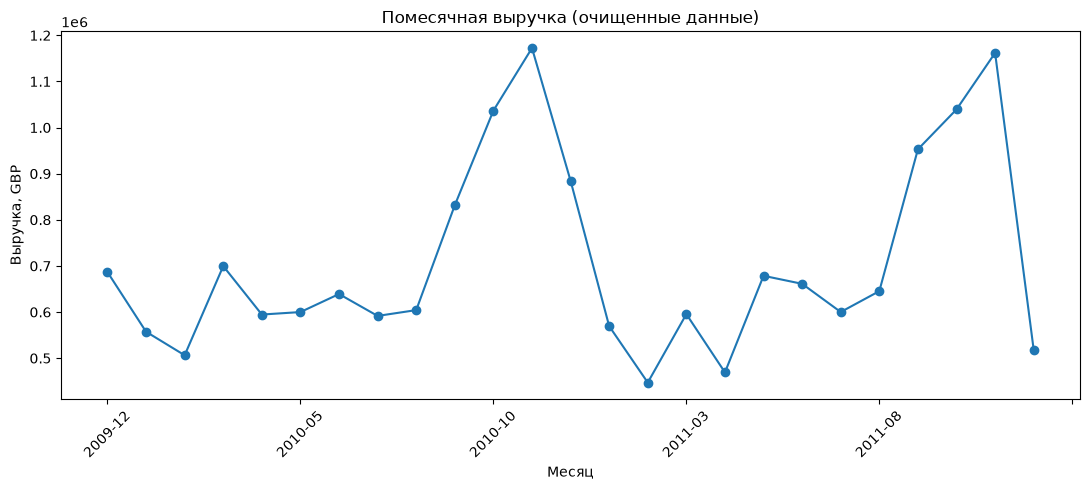

In [7]:
gp = grouped_df.copy()
gp['purchase_month'] = gp['purchase_month'].astype(str)
ax = gp.plot(kind='line', x='purchase_month', y='revenue_agg',
             figsize=(11, 5), marker='o', legend=False)
ax.set_title('Помесячная выручка (очищенные данные)')
ax.set_xlabel('Месяц')
ax.set_ylabel('Выручка, GBP')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5. Когортный анализ Retention

Когорты по месяцу первой покупки, матрица удержания в процентах.

In [8]:
df_cohort = clean.groupby('Customer ID').agg(cohort_month=('purchase_month', 'min'))
clean = pd.merge(clean, df_cohort, on='Customer ID', how='left')
clean['cohort_index'] = ((clean['purchase_month'].dt.year - clean['cohort_month'].dt.year) * 12
                         + (clean['purchase_month'].dt.month - clean['cohort_month'].dt.month))

pivot = clean.groupby(['cohort_month', 'cohort_index'])['Customer ID'].nunique().unstack()
retention = round(pivot.divide(pivot[0], axis=0) * 100, 2)
print(retention.iloc[:10, :6])

cohort_index      0      1      2      3      4      5
cohort_month                                          
2009-12       100.0  35.29  33.40  42.51  38.01  35.92
2010-01       100.0  20.63  31.07  30.55  26.37  30.03
2010-02       100.0  23.80  22.46  29.14  24.60  20.05
2010-03       100.0  18.96  23.02  24.15  23.25  20.32
2010-04       100.0  19.39  19.39  16.33  18.37  22.45
2010-05       100.0  15.75  16.93  17.32  17.72  25.59
2010-06       100.0  17.41  18.89  20.37  22.96  28.52
2010-07       100.0  15.59  18.28  29.57  29.03  13.98
2010-08       100.0  20.37  29.63  32.10  17.28  11.73
2010-09       100.0  22.63  23.46  12.35   9.05  10.29


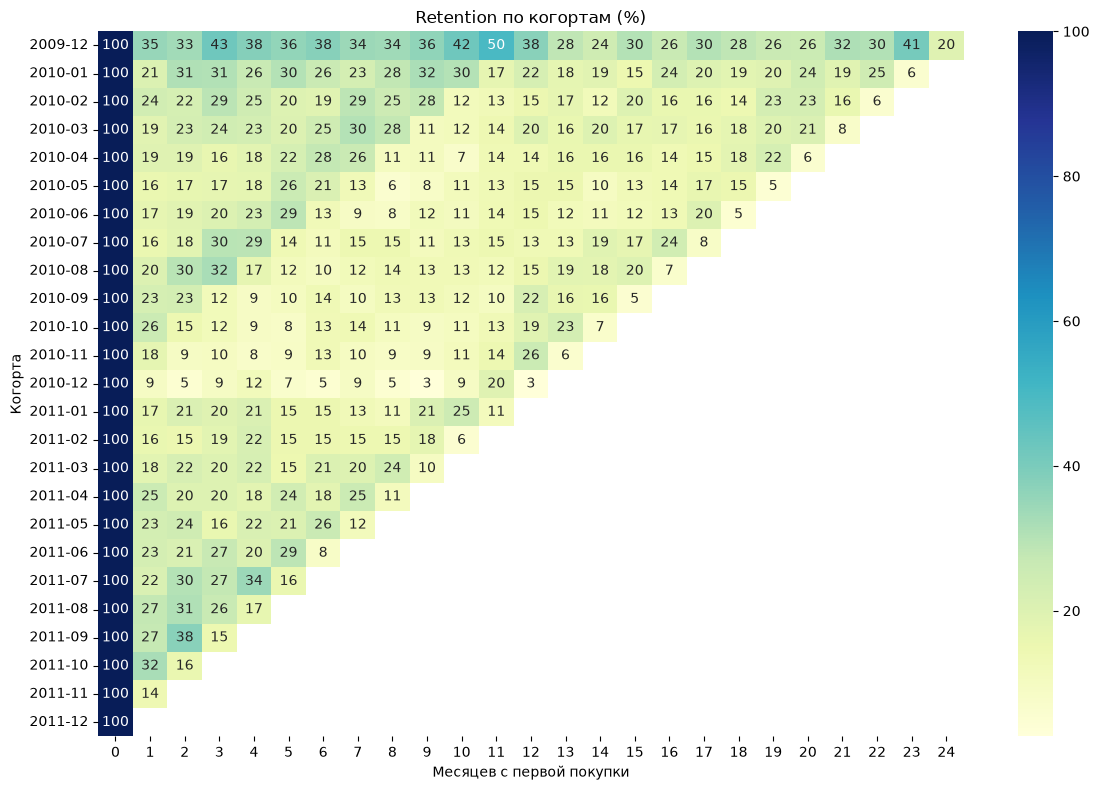

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Retention по когортам (%)')
plt.xlabel('Месяцев с первой покупки')
plt.ylabel('Когорта')
plt.tight_layout()
plt.show()

### 6. Сравнение групп по стране (наблюдательные данные)

**Вопрос:** отличается ли средняя выручка на строку заказа между UK и Германией?

- **H0:** средняя выручка на строку в двух странах равна.
- **H1:** средние различаются.

Снова: это **наблюдательное сравнение**, а не A/B-тест.

In [10]:
group_uk = clean[clean['Country'] == 'United Kingdom']['revenue']
group_ger = clean[clean['Country'] == 'Germany']['revenue']

print('UK:       n =', group_uk.shape[0], '| среднее =', f'{group_uk.mean():.2f}')
print('Германия: n =', group_ger.shape[0], '| среднее =', f'{group_ger.mean():.2f}')

UK:       n = 725250 | среднее = 20.30
Германия: n = 16694 | среднее = 25.83


Используем **Welch t-тест** (дисперсии и размеры групп разные) и непараметрический **тест Манна-Уитни**.

In [11]:
t_stat, p_welch = stats.ttest_ind(group_uk, group_ger, equal_var=False)
print(f'Welch t-тест: t = {t_stat:.2f}, p-value = {p_welch:.2e}')

u_stat, p_mwu = stats.mannwhitneyu(group_uk, group_ger, alternative='two-sided')
print(f'Манна-Уитни:  U = {u_stat:.0f}, p-value = {p_mwu:.2e}')

Welch t-тест: t = -14.38, p-value = 7.54e-47
Манна-Уитни:  U = 3675380468, p-value = 0.00e+00


Размер эффекта — **Cohen's d** и разница средних с 95% ДИ.

In [12]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp

d = cohens_d(group_uk, group_ger)
diff = group_uk.mean() - group_ger.mean()
se = np.sqrt(group_uk.var(ddof=1)/len(group_uk) + group_ger.var(ddof=1)/len(group_ger))
ci_low, ci_high = diff - 1.96 * se, diff + 1.96 * se

print(f'Разница средних (UK - Германия): {diff:.2f} GBP')
print(f'95% ДИ разницы: [{ci_low:.2f}; {ci_high:.2f}] GBP')
print(f"Cohen's d: {d:.3f}")

Разница средних (UK - Германия): -5.53 GBP
95% ДИ разницы: [-6.29; -4.78] GBP
Cohen's d: -0.024


### Выводы

1. **Когортный анализ:** в отличие от Olist, здесь есть повторные покупки, и матрица Retention строится полноценно. Когорта декабря 2009 удерживается заметно лучше последующих; в целом удержание на уровне ~20-40% в первые месяцы говорит о наличии лояльной базы.
2. **Сезонность:** пик выручки приходится на ноябрь-декабрь (предновогодний спрос). ARPPU на очищенных данных ≈ 3019 GBP (в исходной версии было 835 GBP из-за ошибки в формуле — считалась сумма цен за единицу без учёта количества).
3. **Сравнение UK vs Германия — исправление ошибки интерпретации.** В исходной версии вывод гласил: «A/B-тест показал статистически значимую разницу (p=0.46)» — это ошибка сразу по двум причинам: (а) p=0.46 > 0.05 означает, что различие **НЕ** значимо, то есть текст противоречил собственному числу; (б) это вообще не A/B-тест.
4. **Корректный вывод по сравнению групп.** На очищенных данных формальный p-value очень мал (Welch p ≈ 0) — но **исключительно из-за огромного размера выборки** (сотни тысяч строк). **Размер эффекта пренебрежимо мал: Cohen's d ≈ 0.02**, то есть распределения почти совпадают. Вывод: **практически значимых различий между странами не выявлено** — статзначимость здесь артефакт большого n, а не признак реального различия.
5. **Главный урок:** при больших выборках p-value почти всегда мал, поэтому опираться нужно на **размер эффекта** и практическую значимость, а не на факт p < 0.05. И помнить про отсутствие рандомизации: это наблюдательное сравнение, возможны конфаундеры.